# LightGBM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import lightgbm as lgb
from lightgbm import log_evaluation
import time
import re
import joblib
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')
# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
print(f"LightGBM version: {lgb.__version__}")

LightGBM version: 4.6.0


back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import save
print(Path.cwd())

e:\AI_ML\proj\sentiment-analysis-of-amazon-reviews-using-machine-learning-ml-queens\notebooks
E:\AI_ML\proj\sentiment-analysis-of-amazon-reviews-using-machine-learning-ml-queens


## Data Acquisition

load dataset

In [3]:
X_train_tfidf = sp.load_npz('data/vectorizers/X_train_tfidf.npz').tocsr()
print(f"X_train shape: {X_train_tfidf.shape}")
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
print(f"y_train shape: {y_train.shape}")

X_train shape: (79972, 100000)
y_train shape: (79972,)


In [4]:
X_valid = sp.load_npz('data/vectorizers/X_valid_tfidf.npz').tocsr()
print(f"X_valid shape: {X_valid.shape}")
y_valid = pd.read_csv('data/processed/y_valid.csv').squeeze()
print(f"y_valid shape: {y_valid.shape}")

X_valid shape: (20000, 100000)
y_valid shape: (20000,)


In [5]:
X_test_tfidf = sp.load_npz('data/vectorizers/X_test_tfidf.npz').tocsr()
print(f"X_test shape: {X_test_tfidf.shape}")
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()
print(f"y_test shape: {y_test.shape}")

X_test shape: (20000, 100000)
y_test shape: (20000,)


In [6]:
# Convert sparse matrices to dense for LightGBM for compatibilty
X_train_dense = X_train_tfidf.tocsr().astype(np.float32)
# Use sparse CSR float32 to avoid dense allocation (LightGBM accepts sparse matrices)
X_test_dense = X_test_tfidf.tocsr().astype(np.float32)
# Convert [1, 2] labels to [0, 1]
y_train = y_train.astype(int) - 1
y_test = y_test.astype(int) - 1

## Hyperparameter Tuning with RandomizedSearchCV

LightGBM is Microsoft's fast gradient boosting framework, optimized for speed and efficiency.
It handles both sparse and dense data natively and often trains faster than XGBoost while achieving similar or better results.
We use `RandomizedSearchCV` to efficiently explore LightGBM's large hyperparameter space.
RandomizedSearchCV is preferred because LightGBM has a very large parameter space with leaf-wise tree growth.

> **Key Hyperparameters for LightGBM:**
> - `n_estimators`: Number of boosting rounds
> - `learning_rate`: Shrinkage parameter (step size)
> - `num_leaves`: Maximum number of leaves in a tree (LightGBM specific)
> - `max_depth`: Maximum tree depth (limits by depth)
> - `subsample`: Fraction of samples for tree building
> - `colsample_bytree`: Fraction of features for tree building
> - `min_child_samples`: Minimum samples in leaf node
> - `reg_alpha`: L1 regularization
> - `reg_lambda`: L2 regularization

In [7]:
# Define the hyperparameter search space for LightGBM
param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],           # Number of boosting rounds
    'learning_rate': [0.01, 0.05, 0.1, 0.15],           # Step size
    'num_leaves': [15, 31, 63, 127],                    # Tree complexity (LightGBM specific)
    'max_depth': [5, 7, 10, 15],                        # Max depth (limits)
    'subsample': [0.6, 0.7, 0.8, 0.9],                  # Row sampling
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],           # Feature sampling
    'min_child_samples': [5, 10, 20, 30],               # Min samples in leaf
    'reg_alpha': [0, 0.1, 0.5, 1.0],                    # L1 regularization
    'reg_lambda': [0.5, 1.0, 1.5, 2.0],                 # L2 regularization
}
# Base estimator — LGBMClassifier
base_lgb = lgb.LGBMClassifier(random_state=42, n_jobs=10, verbose=-1)
print("Starting RandomizedSearchCV for LightGBM...")
search_start = time.time()
random_search = RandomizedSearchCV(
    estimator=base_lgb,
    param_distributions=param_dist,
    n_iter=20,                 # Test 20 random combinations (large space, but smaller than XGB)
    scoring='f1',              # Optimize for F1 (balanced metric for binary sentiment)
    cv=3,                      # 3-fold cross-validation on training data
    random_state=42,
    n_jobs=10,                 # Use all available cores
    verbose=2,
    refit=True                 # Refit best model on the full training set
)
random_search.fit(X_train_dense, y_train)
search_time = time.time() - search_start
print(f"\nRandomizedSearchCV completed in {search_time:.4f} seconds")

Starting RandomizedSearchCV for LightGBM...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

RandomizedSearchCV completed in 736.6986 seconds


In [8]:
# Inspect the best hyperparameters found
print("Best Parameters:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV F1-Score: {random_search.best_score_:.4f}")

Best Parameters:
  subsample: 0.7
  reg_lambda: 2.0
  reg_alpha: 0.1
  num_leaves: 63
  n_estimators: 200
  min_child_samples: 30
  max_depth: 15
  learning_rate: 0.15
  colsample_bytree: 0.9

Best CV F1-Score: 0.8611


In [9]:
# CV results summary — top 10 combinations
cv_results = pd.DataFrame(random_search.cv_results_)
top_results = (
    cv_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score')
    .head(10)
)
print("Top 10 hyperparameter combinations (by F1):")
print(top_results.to_string(index=False))

Top 10 hyperparameter combinations (by F1):
                                                                                                                                                                                  params  mean_test_score  std_test_score  rank_test_score
{'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'num_leaves': 63, 'n_estimators': 200, 'min_child_samples': 30, 'max_depth': 15, 'learning_rate': 0.15, 'colsample_bytree': 0.9}         0.861087        0.001422                1
 {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.5, 'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.6}         0.858023        0.001067                2
{'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 30, 'max_depth': 10, 'learning_rate': 0.15, 'colsample_bytree': 0.9}         0.856859        0.000282                3
 {'subsample': 0

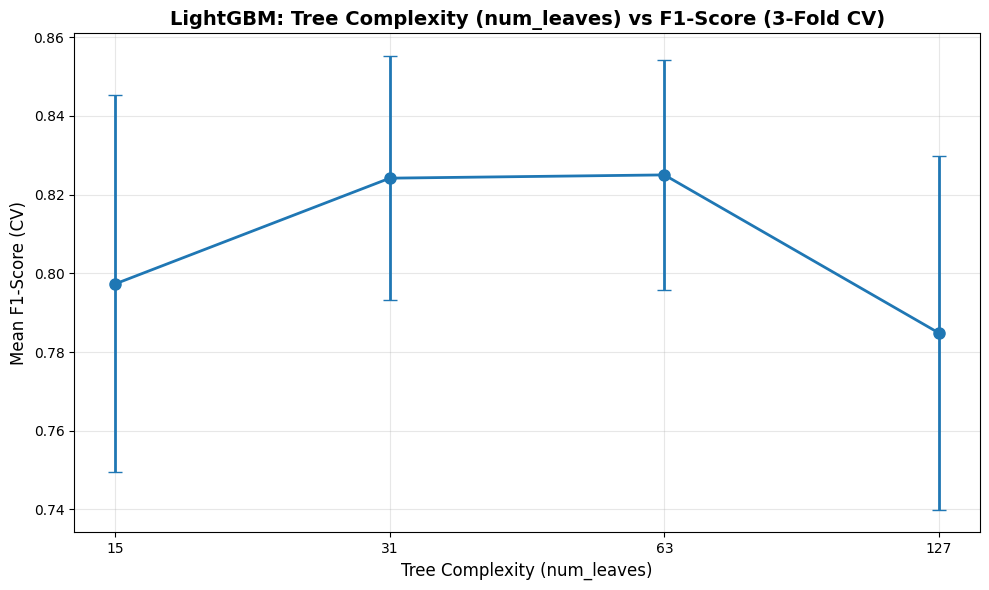


Tree Complexity (num_leaves) Performance Analysis:
 num_leaves     mean      std
         15 0.797318 0.047923
         31 0.824175 0.031035
         63 0.825002 0.029188
        127 0.784840 0.044927


In [ ]:
# Analyze the effect of num_leaves (tree complexity) on F1-score
cv_df = pd.DataFrame(random_search.cv_results_)
cv_df['num_leaves'] = cv_df['params'].apply(lambda x: x['num_leaves'])
# Average performance by num_leaves
leaves_performance = cv_df.groupby('num_leaves')['mean_test_score'].agg(['mean', 'std']).reset_index()
leaves_performance = leaves_performance.sort_values('num_leaves')
# Plot num_leaves sensitivity
plt.figure(figsize=(10, 6))
plt.errorbar(np.arange(len(leaves_performance)), leaves_performance['mean'], 
             yerr=leaves_performance['std'], marker='o', capsize=5, linewidth=2, markersize=8)
plt.xlabel('Tree Complexity (num_leaves)', fontsize=12)
plt.ylabel('Mean F1-Score (CV)', fontsize=12)
plt.title('LightGBM: Tree Complexity (num_leaves) vs F1-Score (3-Fold CV)', fontsize=14, fontweight='bold')
plt.xticks(np.arange(len(leaves_performance)), leaves_performance['num_leaves'].astype(int))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('docs/02_results/lgb_num_leaves_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nTree Complexity (num_leaves) Performance Analysis:")
print(leaves_performance.to_string(index=False))

## LightGBM Model Training with Optimized Hyperparameters

We use the best parameters discovered via RandomizedSearchCV and train the final model on the **full** training set (already done by `refit=True` in `RandomizedSearchCV`).

In [11]:
# Retrieve the best estimator (already refit on the full training set)
lgb_classifier = random_search.best_estimator_
print(f"Final LightGBM Model trained with best hyperparameters:")
print(f"  Training set size: {X_train_dense.shape}")
print(f"  Number of Estimators: {lgb_classifier.n_estimators}")
print(f"  Number of Leaves: {lgb_classifier.num_leaves}")
print(f"  Learning Rate: {lgb_classifier.learning_rate}")
print(f"  F1-Score (CV): {random_search.best_score_:.4f}")

Final LightGBM Model trained with best hyperparameters:
  Training set size: (79972, 100000)
  Number of Estimators: 200
  Number of Leaves: 63
  Learning Rate: 0.15
  F1-Score (CV): 0.8611


## Model Evaluation

In [12]:
# Make predictions
y_pred = lgb_classifier.predict(X_test_dense)
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Print results
print("LIGHTGBM CLASSIFIER - PERFORMANCE METRICS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Training Time: {search_time:.4f} seconds")

LIGHTGBM CLASSIFIER - PERFORMANCE METRICS
Accuracy:  0.8612
Precision: 0.8566
Recall:    0.8689
F1-Score:  0.8627
Training Time: 736.6986 seconds


## Classification Report

In [13]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.85      0.86      9966
    Positive       0.86      0.87      0.86     10034

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000



## Confusion Matrix Visualization

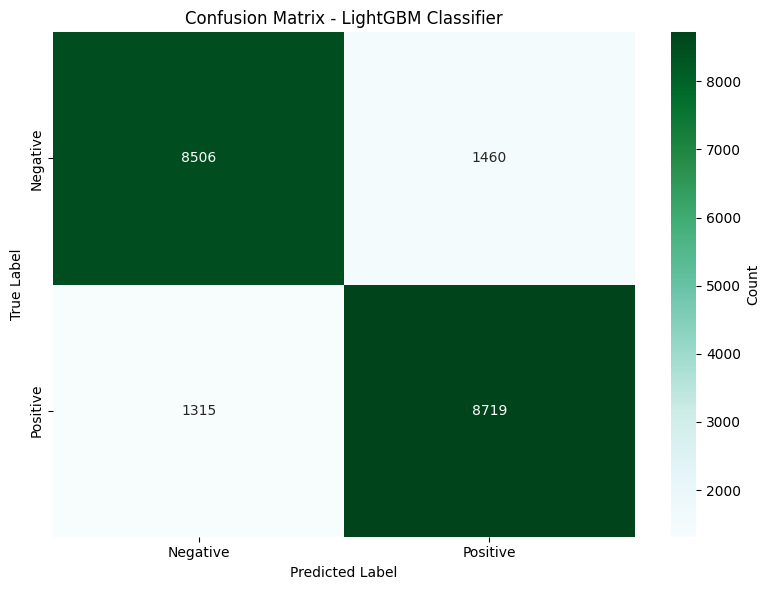

Confusion Matrix:
[[8506 1460]
 [1315 8719]]

True Negatives: 8506
False Positives: 1460
False Negatives: 1315
True Positives: 8719


In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='BuGn',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - LightGBM Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('docs/02_results/lightgbm_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

## Feature Importance

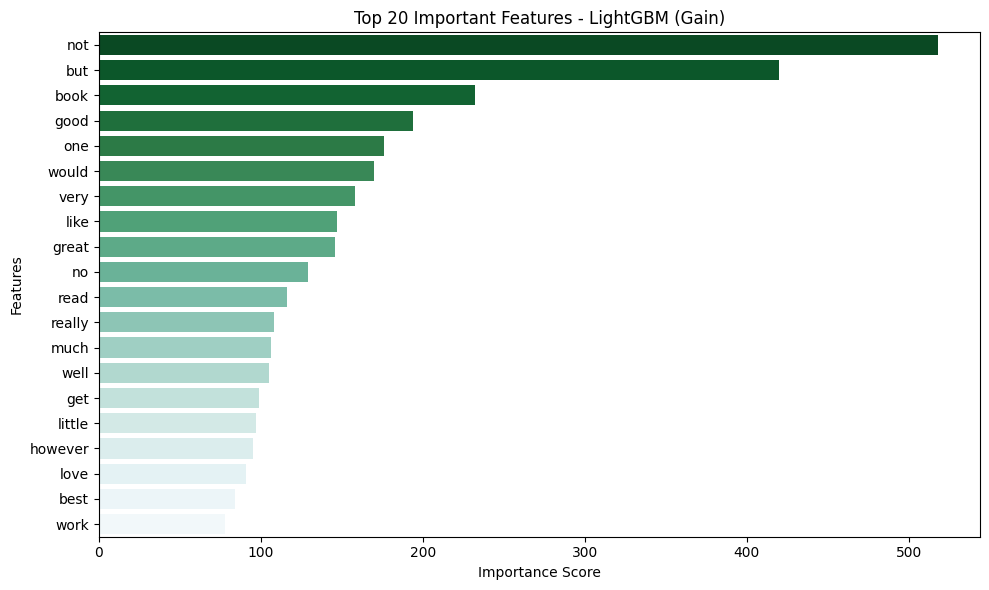


Top 20 Important Features:
feature  importance
    not         518
    but         420
   book         232
   good         194
    one         176
  would         170
   very         158
   like         147
  great         146
     no         129
   read         116
 really         108
   much         106
   well         105
    get          99
 little          97
however          95
   love          91
   best          84
   work          78


In [ ]:
# Get feature importance
tfidf_vectorizer = joblib.load('data/vectorizers/tfidf_vectorizer.joblib')
feature_names = tfidf_vectorizer.get_feature_names_out()
importances = lgb_classifier.feature_importances_
# Create DataFrame for better visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)
# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='BuGn_r')
plt.title('Top 20 Important Features - LightGBM (Gain)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('docs/02_results/lightgbm_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nTop 20 Important Features:")
print(importance_df.to_string(index=False))

## Feature Importance by Type

In [16]:
# Get feature importance by split (how many times feature is used for splitting)
split_importance = lgb_classifier.booster_.feature_importance(importance_type='split')
# Create DataFrame
split_df = pd.DataFrame({
    'feature': feature_names,
    'split_count': split_importance
}).sort_values('split_count', ascending=False).head(10)
print("Top 10 Features by Split Count (How often used for splitting):")
print(split_df.to_string(index=False))

Top 10 Features by Split Count (How often used for splitting):
feature  split_count
    not          518
    but          420
   book          232
   good          194
    one          176
  would          170
   very          158
   like          147
  great          146
     no          129


## Model Summary

In [ ]:
print("LIGHTGBM MODEL SUMMARY")
print(f"\nModel Parameters:")
print(f"  - Number of Estimators: {lgb_classifier.n_estimators}")
print(f"  - Max Depth: {lgb_classifier.max_depth}")
print(f"  - Learning Rate: {lgb_classifier.learning_rate}")
print(f"  - Num Leaves: {lgb_classifier.num_leaves}")
print(f"  - Min Child Samples: {lgb_classifier.min_child_samples}")
print(f"  - Subsample: {lgb_classifier.subsample}")
print(f"  - Colsample by Tree: {lgb_classifier.colsample_bytree}")
print(f"\nFeature Engineering:")
print(f"  - Vectorizer: TF-IDF")
print(f"  - Max Features: 100000")
print(f"  - N-gram Range: (1, 2)")
print(f"  - Min Document Frequency: 5")
print(f"  - Max Document Frequency: 0.8")
print(f"\nPerformance:")
print(f"  - Accuracy:  {accuracy:.4f}")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")
print(f"  - Training Time: {search_time:.4f} seconds")
print(f"\nModel Characteristics:")
print(f"  - Boosting Type: gbdt (Gradient Boosting Decision Tree)")
print(f"  - Tree Learner: serial")
print(f"  - Objective: binary_logloss")
print(f"  - Speed Advantage: Fastest among tree-based models")

LIGHTGBM MODEL SUMMARY

Model Parameters:
  - Number of Estimators: 200
  - Max Depth: 15
  - Learning Rate: 0.15
  - Num Leaves: 63
  - Min Child Samples: 30
  - Subsample: 0.7
  - Colsample by Tree: 0.9

Feature Engineering:
  - Vectorizer: TF-IDF
  - Max Features: 5000
  - N-gram Range: (1, 2)
  - Min Document Frequency: 5
  - Max Document Frequency: 0.8

Performance:
  - Accuracy:  0.8612
  - Precision: 0.8566
  - Recall:    0.8689
  - F1-Score:  0.8627
  - Training Time: 736.6986 seconds

Model Characteristics:
  - Boosting Type: gbdt (Gradient Boosting Decision Tree)
  - Tree Learner: serial
  - Objective: binary_logloss
  - Speed Advantage: Fastest among tree-based models


## Saving the Model and Pipeline

In [18]:
save(model_base='data/models', model=lgb_classifier, model_name='13_lightgbm_classifier.joblib')

Saved model 13_lightgbm_classifier.joblib to data\models\13_lightgbm_classifier.joblib


{'model': WindowsPath('data/models/13_lightgbm_classifier.joblib')}